In [ ]:
#distance map PDB to HMM
from sequenceHandler import mapPDBToHMM
pdb_file = "1AAL.pdb"
chain_id = "A"
hmm_file = "PF00014.hmm"
hmm_file_2 = "None"        
output_map_file = "distance_map.txt"  

distance_map,map_index = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
print(distance_map)
print(map_index)

c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1359.
  warnings.warn(
c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1417.
  warnings.warn(


[<Residue ARG het=  resseq=1 icode= >, <Residue PRO het=  resseq=2 icode= >, <Residue ASP het=  resseq=3 icode= >, <Residue PHE het=  resseq=4 icode= >, <Residue CYS het=  resseq=5 icode= >, <Residue LEU het=  resseq=6 icode= >, <Residue GLU het=  resseq=7 icode= >, <Residue PRO het=  resseq=8 icode= >, <Residue PRO het=  resseq=9 icode= >, <Residue TYR het=  resseq=10 icode= >, <Residue THR het=  resseq=11 icode= >, <Residue GLY het=  resseq=12 icode= >, <Residue PRO het=  resseq=13 icode= >, <Residue CYS het=  resseq=14 icode= >, <Residue LYS het=  resseq=15 icode= >, <Residue ALA het=  resseq=16 icode= >, <Residue ARG het=  resseq=17 icode= >, <Residue ILE het=  resseq=18 icode= >, <Residue ILE het=  resseq=19 icode= >, <Residue ARG het=  resseq=20 icode= >, <Residue TYR het=  resseq=21 icode= >, <Residue PHE het=  resseq=22 icode= >, <Residue TYR het=  resseq=23 icode= >, <Residue ASN het=  resseq=24 icode= >, <Residue ALA het=  resseq=25 icode= >, <Residue LYS het=  resseq=26 icod

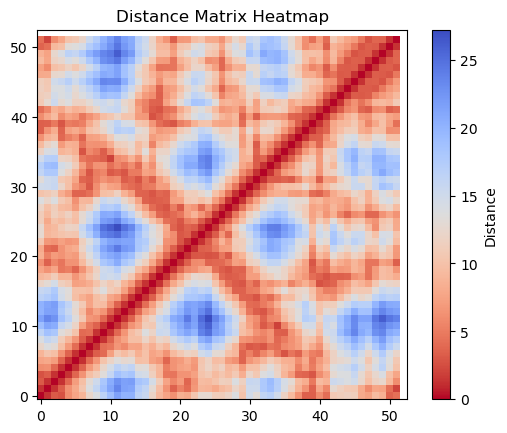

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()

In [ ]:
from sequenceHandler import  stockholm2fasta,filterSequenceByGapContent,do_DCA,get_pfam_msa, extract_scop_ids
from sequenceHandler import mapPDBToHMM
import pickle
import requests
from pathlib import Path
import gzip
import shutil
import subprocess

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def _make_session():
    session = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        status=5,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=1, pool_maxsize=1)
    session.mount("https://", adapter)
    session.headers.update(
        {
            "User-Agent": "Mozilla/5.0",
            "Connection": "close",
            "Accept": "*/*",
        }
    )
    return session

with open("pfam_list.txt", "r") as f:
    pfam_ids = [line.strip() for line in f]


for pfam_id in pfam_ids:
    data={}
    print(pfam_id)

    # Get the MSA in Stockholm format and save it to a file
    msa = get_pfam_msa(pfam_id, kind="full")
    out_sto = f'C:/Users/gfabi/Desktop/Internship/MSA/msa_{pfam_id}.sto'
    with open(out_sto, "wb") as f:
        f.write(msa)

    # Extract the PDB ID from the Stockholm file and download the corresponding PDB file
    pdb_id = extract_scop_ids(out_sto)
    print(pdb_id)
    resp = requests.get(url=f"https://files.rcsb.org/download/{pdb_id[0].upper()}.pdb")
    out_pdb = f'C:/Users/gfabi/Desktop/Internship/PDB/{pfam_id}.pdb'
    with open(out_pdb, "wb") as f:
        f.write(resp.content)

    # Get the HMM file for the Pfam family
    accession = pfam_id
    out_dir="HMM"
    accession = accession.strip().upper()

    if not accession.startswith("PF") or len(accession) != 7:
        raise ValueError("Expected a Pfam accession like PF00042")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    gz_path = out_dir / f"{accession}.hmm.gz"
    hmm_path = out_dir / f"{accession}.hmm"

    url = f"https://www.ebi.ac.uk/interpro/api/entry/pfam/{accession}?annotation=hmm"

    # First try pure Python requests with retries
    try:
        session = _make_session()
        with session.get(url, stream=True, timeout=(20, 120)) as r:
            r.raise_for_status()
            with open(gz_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 64):
                    if chunk:
                        f.write(chunk)

    except requests.exceptions.SSLError:
        # Fallback: use curl if available, which often succeeds where requests/OpenSSL fails
        curl = shutil.which("curl") or shutil.which("curl.exe")
        if not curl:
            raise RuntimeError(
                "SSL error from requests, and curl was not found on PATH."
            )

        cmd = [
            curl,
            "-L",
            "--fail",
            "--retry",
            "5",
            "--retry-delay",
            "2",
            "--connect-timeout",
            "20",
            "-o",
            str(gz_path),
            url,
        ]
        subprocess.run(cmd, check=True)

    # Decompress .gz -> .hmm
    with gzip.open(gz_path, "rb") as fin, open(hmm_path, "wb") as fout:
        shutil.copyfileobj(fin, fout)    

    #contanct map of the PDB and sequence
    from sequenceHandler import mapPDBToHMM
    pdb_file = f"C:/Users/gfabi/Desktop/Internship/PDB/{pfam_id}.pdb"
    chain_id = "A"
    hmm_file = f"C:/Users/gfabi/Desktop/Internship/HMM/{pfam_id}.hmm"
    hmm_file_2 = "None"        
    output_map_file = "None"  

    distance_map,map_index,aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')

    # Takes the MSA of the family, convert Stockholm to FASTA, filter sequences by gap content, and perform DCA
    out_fasta= f'C:/Users/gfabi/Desktop/Internship/MSA/msa_{pfam_id}.fasta' 
    stockholm2fasta(out_sto,out_fasta)
    filterSequenceByGapContent(out_fasta, 0.2, out_fasta)
    score_map = do_DCA(out_fasta)
    

    data = {
        'sequence': aligned_sequence,
        'distance_map': distance_map,
        'dca': score_map
    }

    with open(f"Data/data_{pfam_id}.pkl", "wb") as f:
        pickle.dump(data, f)

PF00001
['1f88']


c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 5858.
  warnings.warn(
c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 5883.
  warnings.warn(
c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 5908.
  warnings.warn(
c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 5924.
  warnings.warn(


STDERR: 
Original number of sequences  289903
Sequences after filtering :  233577
Filtered sequences saved to  C:/Users/gfabi/Desktop/Internship/MSA/msa_PF00001.fasta


In [71]:
import pickle

pfam_id = "PF00031"
with open(f"Data/data_{pfam_id}.pkl", "rb") as f:
    loaded = pickle.load(f)

sequence=loaded['sequence'] 
distance_map=loaded['distance_map']
contact_map_DCA=loaded['dca']

In [72]:
print(sequence)

['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-']


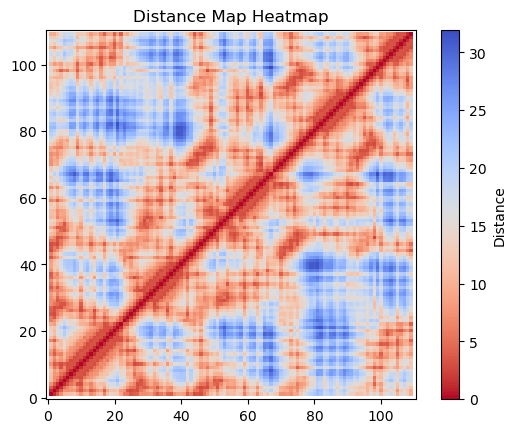

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Map Heatmap")
plt.show()

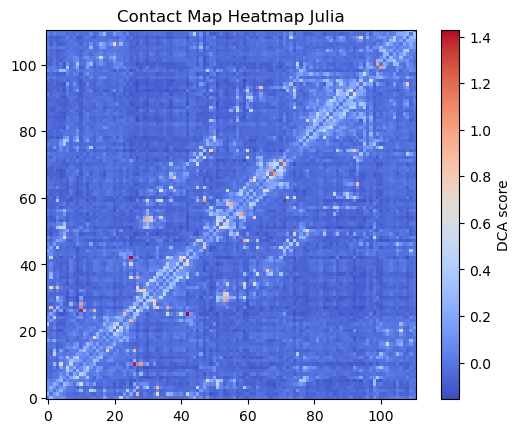

In [19]:
plt.figure()
plt.imshow(contact_map_DCA,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA score")
plt.title("Contact Map Heatmap Julia")
plt.show()

In [10]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

folder_path = "Data"

total_distances = []
total_scrores = []

for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence'] 
        #print(sequence)



        distance_map=loaded['distance_map']

        #Extract unique distances (no diagonal, no duplicates)
        distances = distance_map[np.triu_indices_from(distance_map, k=1)]

        # Remove invalid values
        distances = distances[np.isfinite(distances)]
        total_distances.extend(distances)
        # # Plot
        # plt.figure()
        # plt.hist(distances, bins=50, density=True)
        # plt.xlabel("Distance (Å)")
        # plt.ylabel("Density")
        # plt.title("Distance Distribution")
        # plt.show()



        contact_map_DCA=loaded['dca']

        # Extract unique distances (no diagonal, no duplicates)
        distances = contact_map_DCA[np.triu_indices_from(contact_map_DCA, k=1)]
        total_scrores.extend(distances) 
        # # Plot
        # plt.figure()
        # plt.hist(distances, bins=50, density=True)
        # plt.xlabel("DCA Score")
        # plt.ylabel("Density")
        # plt.title("DCA Score Distribution")
        # plt.show()




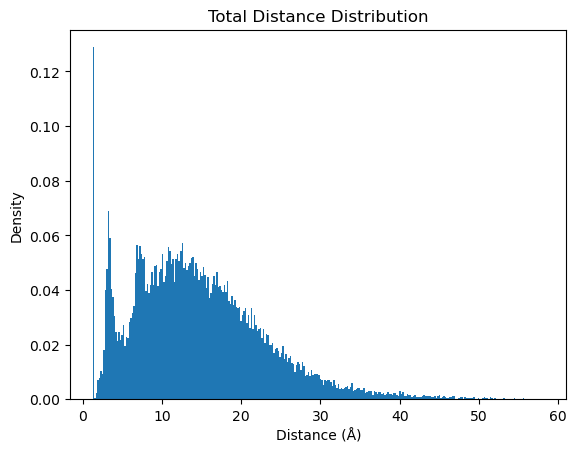

In [11]:
plt.figure()
plt.hist(total_distances, bins=300, density=True)
plt.xlabel("Distance (Å)")
plt.ylabel("Density")
plt.title("Total Distance Distribution")
plt.show()

14.61059893048976 8.377822685174843


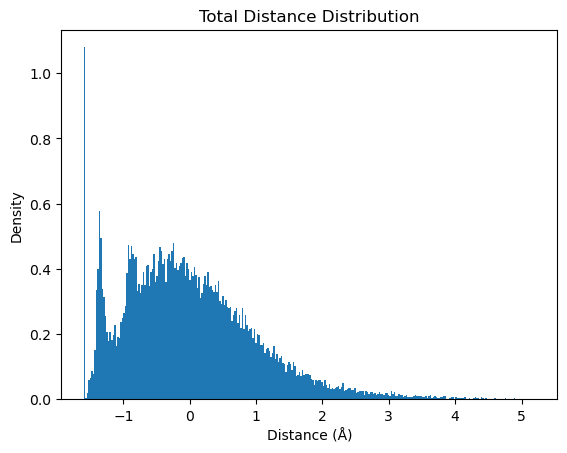

In [15]:
m=min(total_distances)
mean=np.mean(total_distances)
sigma=np.std(total_distances)
print(mean, sigma) 
plt.figure()
plt.hist((np.array(total_distances)-mean)/sigma, bins=300, density=True)
plt.xlabel("Distance (Å)")
plt.ylabel("Density")
plt.title("Total Distance Distribution")
plt.show()

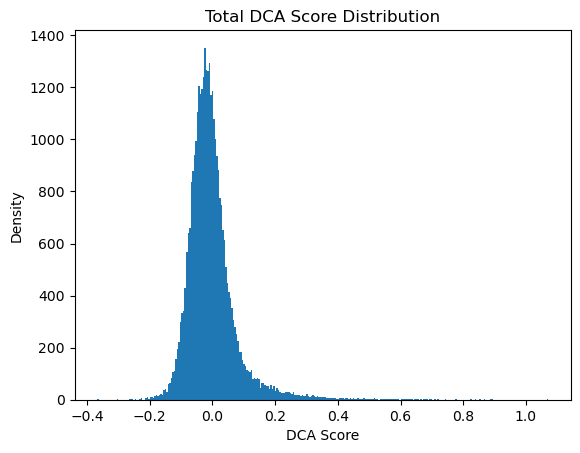

In [13]:
plt.figure()
#t_d = [d for d in total_distances if d > 1.34] 
plt.hist(np.log(np.array(total_scrores)+1), bins=300, density=False)
plt.xlabel("DCA Score")
plt.ylabel("Density")
plt.title("Total DCA Score Distribution")
plt.show()